In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Свойства точечных оценок - 2

На прошлой неделе мы обсуждали **моменты распределений** и другие свойства случайных величин

# От асимптотики к фиксированному $n$

Пусть $X_1,\ldots,X_n$ — независимые одинаково распределённые наблюдения, распределение которых зависит от неизвестного параметра $\theta$.

**Точечная оценка** параметра $\theta$ — это статистика

$$\widehat\theta=T(X_1,\ldots,X_n).$$

То есть $\widehat\theta$ вычисляется по выборке и сама является случайной величиной.

Например, если $X_i$ показывает, совершил ли $i$-й пользователь покупку, то

$$X_i\sim\operatorname{Bernoulli}(p),$$

а естественной оценкой конверсии $p$ является выборочная доля

$$\widehat p=\frac{1}{n}\sum_{i=1}^n X_i=\overline X.$$

Если $X_i$ — чек пользователя с математическим ожиданием $\mu$, естественным кандидатом на оценку $\mu$ является $\overline X$.

Пока мы **не обсуждаем способы построения оценок**. Будем считать, что некоторый кандидат $\widehat\theta$ уже предложен, и учиться оценивать его качество.

Метод моментов и метод максимального правдоподобия появятся позже.

Для сравнения оценок при фиксированном $n$ нам понадобятся несколько характеристик.

| Свойство | Что спрашиваем |
|---|---|
| Смещение | В правильную ли точку в среднем попадает оценка? |
| Дисперсия | Насколько сильно оценка меняется от выборки к выборке? |
| MSE | Насколько далеко оценка в среднем находится от параметра? |
| Эффективность | Насколько мала дисперсия относительно доступного теоретического предела? |
| Оптимальность | Можно ли найти другую несмещённую оценку с меньшей дисперсией? |

# Смещение и несмещённость

**Смещением** оценки $\widehat\theta$ называется величина

$$\operatorname{Bias}_\theta(\widehat\theta)=\mathbb{E}_\theta[\widehat\theta]-\theta.$$

Если для любого допустимого $\theta$

$$\mathbb{E}_\theta[\widehat\theta]=\theta,$$

то оценка называется **несмещённой**.

Несмещённость **не означает**, что на конкретной выборке получится точное значение параметра.

Она означает другое: если много раз повторять сбор выборки одинакового размера и каждый раз вычислять $\widehat\theta$, то среднее значение полученных оценок будет равно истинному $\theta$.

## Пример. Сравнение четырёх оценок матожидания

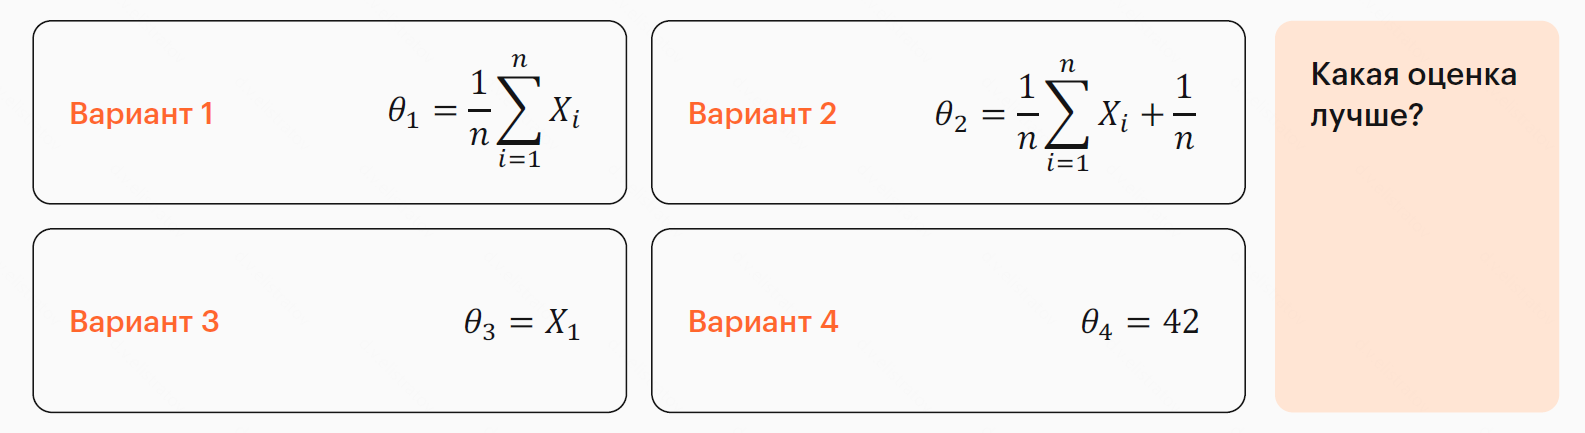

**Рассмотрим оценки на предмет несмещённости**

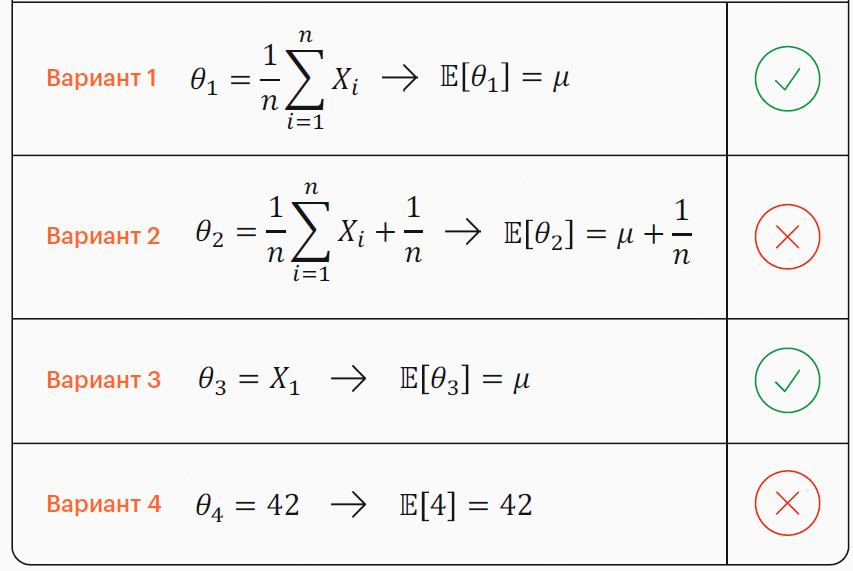

**Рассмотрим оценки на предмет состоятельности**

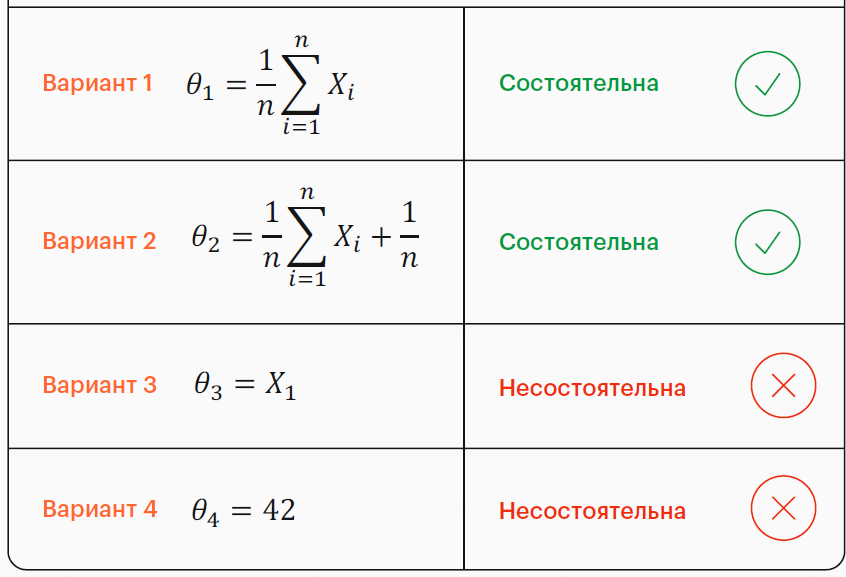

**Итог**

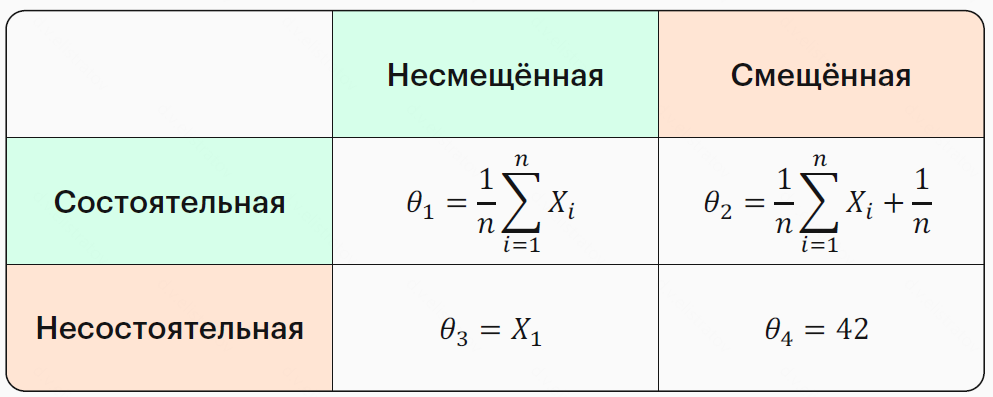

**Теперь продемонстрируем свойства состоятельности и несмещённости этих 4 оценок с помощью симуляций для различных $N$**.

Создадим нормальное распределение с параметрами $\mu=650$ и $\sigma=300$.

Затем создадим миллион наблюдений и рассчитаем среднее из этого миллиона наблюдений.

In [ ]:
# Параметры нормального распределения
mu, sd = 650, 300

# Создаем генеральную совокупность из 1 миллиона наблюдений
user_spend_gp = np.random.normal(mu, sd, 10**6)

# Реальное среднее генеральной совокупности
real_mean = np.mean(user_spend_gp)
print(f"Реальное среднее генеральной совокупности: {real_mean:.2f}")

Реальное среднее генеральной совокупности: 649.92


Для любого размера выборки нам потребуется $50$ испытаний (переменная *n_trials*).

Размеры выборок будем хранитьв векторе *sample_sizes*.

Для хранения результатов расчётов оценок создадим по пустому списку для каждой из оценок.

In [ ]:
n_trials = 50
sample_sizes = range(100, 10100, 100)

# Списки для хранения оценок
estimates = {
    'theta1': [],
    'theta2': [],
    'theta3': [],
    'theta4': []
}

Пробежимся по всем размерам выборки и для каждого произведём расчёт всех 4 оценок на *n_trials* экспериментах.

In [ ]:
for n in sample_sizes:

    # Генерируем случайные выборки размера n * n_trials
    samples = np.random.choice(user_spend_gp, size=(n, n_trials), replace=False)

    # Вычисляем выборочное среднее для каждого испытания
    sample_means = np.mean(samples, axis=0)

    # Вычисляем все четыре оценки
    estimates['theta1'].append(sample_means)
    estimates['theta2'].append(sample_means + 1/n)
    estimates['theta3'].append(samples[0, :])
    estimates['theta4'].append(np.full(n_trials, 42))

Списки превратим в numpy-arrays.

In [ ]:
theta1_arr = np.array(estimates['theta1'])
theta2_arr = np.array(estimates['theta2'])
theta3_arr = np.array(estimates['theta3'])
theta4_arr = np.array(estimates['theta4'])

Создаем список всех оценок для удобного перебора в визуализации.

In [ ]:
all_estimates = [theta1_arr, theta2_arr, theta3_arr, theta4_arr]
estimate_names = ['θ1','θ2','θ3','θ4']

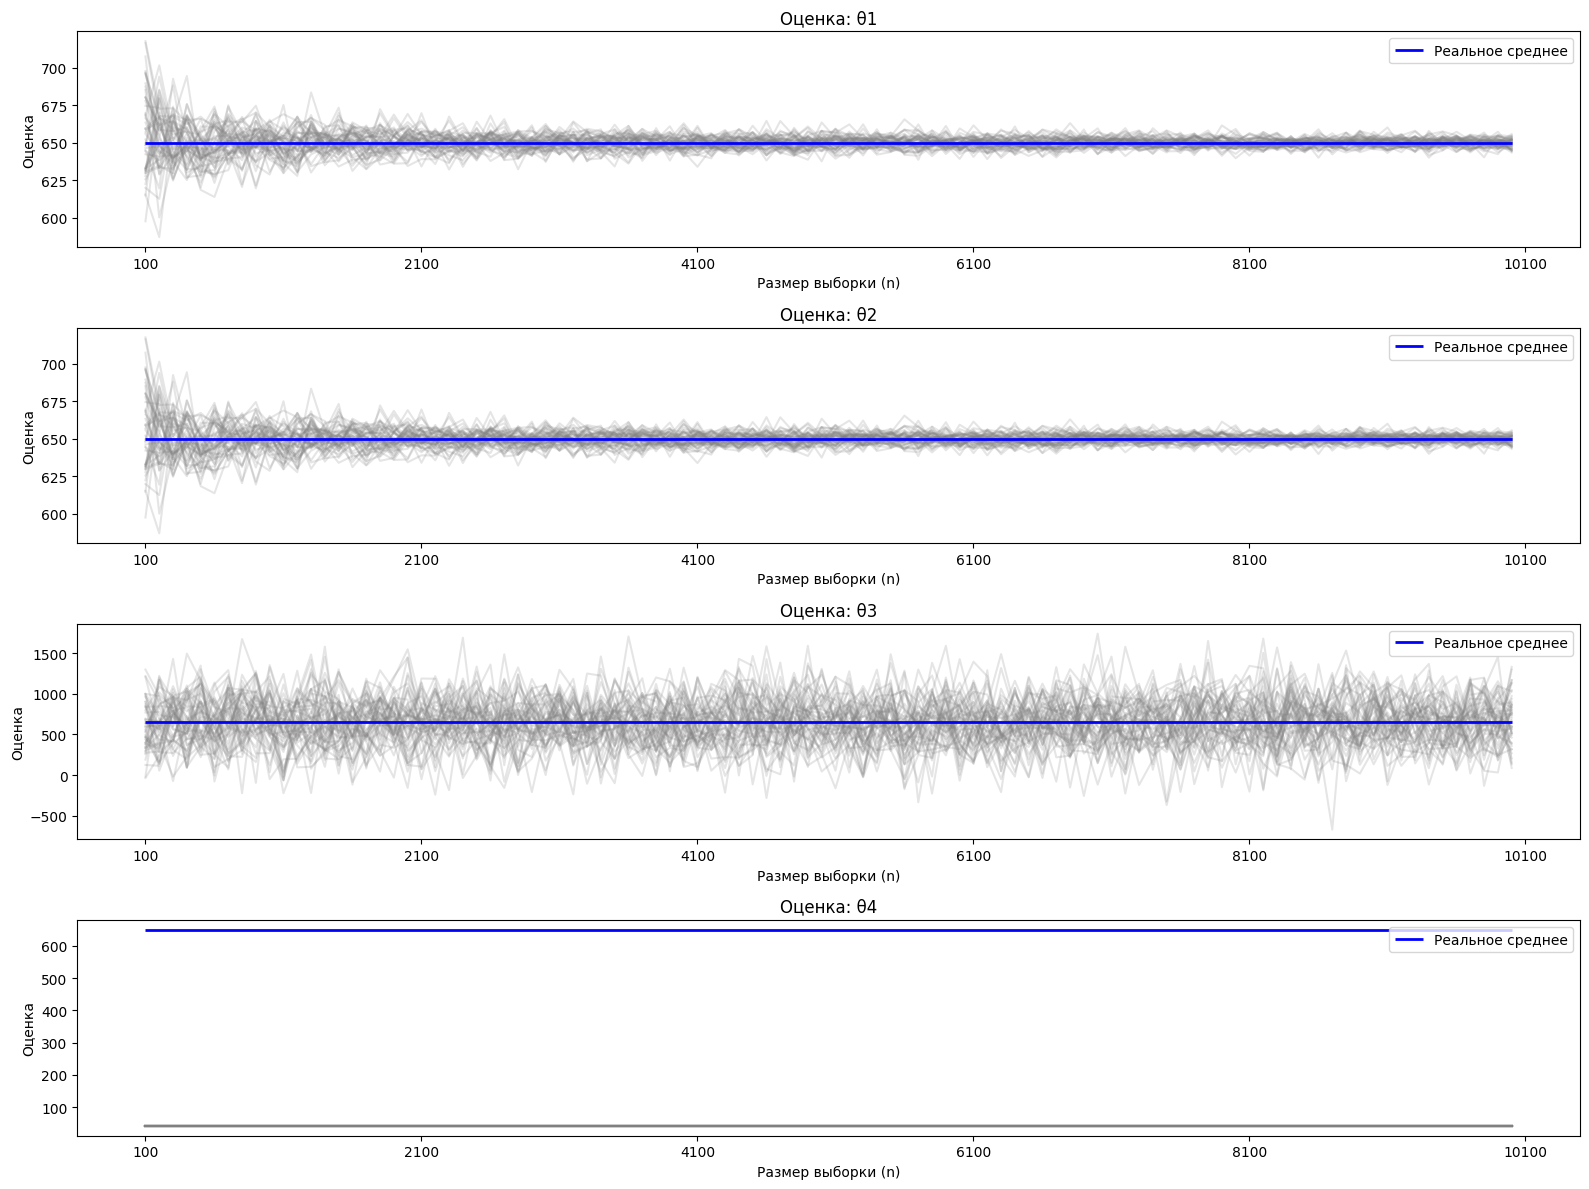

In [ ]:
plt.figure(figsize=(16, 12))

for i, (estimate, name) in enumerate(zip(all_estimates, estimate_names)):
    plt.subplot(4, 1, i+1)

    # Отображаем все trials серыми линиями
    plt.plot(estimate, c='grey', alpha=0.2)

    # Добавляем линию реального среднего
    plt.hlines(real_mean, 0, len(sample_sizes)-1,
               color='blue', lw=2, label='Реальное среднее')

    # Настройки графика
    plt.xlabel('Размер выборки (n)')
    plt.ylabel('Оценка')
    plt.title(f'Оценка: {name}')
    plt.legend()

    # Настройка осей X
    x_ticks_positions = range(0, 101, 20)
    x_ticks_labels = [100 + 100 * pos for pos in x_ticks_positions]
    plt.xticks(x_ticks_positions, x_ticks_labels)

plt.tight_layout()
plt.show()

## Пример. Оценка конверсии

Пусть $X_i\sim\operatorname{Bernoulli}(p)$, где $X_i=1$ означает конверсию пользователя, а $X_i=0$ — её отсутствие.

Тогда $\mathbb{E}[X_i]=p$, поэтому

$$\mathbb{E}[\widehat p]=\mathbb{E}[\overline X]=p.$$

Значит, обычная выборочная конверсия — **несмещённая** оценка истинной конверсии $p$.

## Пример. Оценка дисперсии. Смещённость и несмещённость

Теперь продемонстрируем свойства состоятельности и несмещённости с помощью симуляций для различных $n$.

Создадим нормальное распределение с параметрами $\mu = 650$ и $\sigma = 300$.

In [ ]:
# Параметры нормального распределения
mu, sd = 650, 300

Затем создадим миллион наблюдений и рассчитаем среднее из этого миллиона наблюдений.

Рассчитаем эмпирическое среднее и запишем его в переменную *real_mean*.

In [ ]:
# Создаем генеральную совокупность из 1 миллиона наблюдений
user_spend_gp = np.random.normal(mu, sd, 10**6)

# Реальное среднее генеральной совокупности
real_mean = np.mean(user_spend_gp)
print(f"Среднее = {real_mean:.2f}")

Среднее = 649.93


Создаём пустые списки для хранения оценок смещённой и несмещённой дисперсии.

In [ ]:
biased_vars, unbiased_vars = [], []

Для каждого размера выборки рассчитаем значения смещённой и несмещённой дисперсии.

Будем использовать параметр *ddof* (degrees of freedom) функции *var* из *numpy*.

 - ddof $= 0$  - дисперсия генеральной совокупности (смещённая);
 - ddof $= 1$ - дисперсия генеральной совокупности (несмещённая);

In [ ]:
n_trials = 50

for n in range(100, 10100, 100):
  # на одной итерации получаем n_trials оценок
  # при семплировании из генсовокупности n наблюдений
  rand_smpl = np.random.choice(user_spend_gp, size=(n, n_trials), replace=False)
  biased_var = np.var(rand_smpl, ddof=0, axis=0)
  unbiased_var = np.var(rand_smpl, ddof=1, axis=0)

  # каждый результат расчёта прикрепляем к соответствующему списку
  biased_vars.append(biased_var)
  unbiased_vars.append(unbiased_var)

Приведём векторы с дисперсиями к формату *numpy-array*.

In [ ]:
biased_vars, unbiased_vars = np.array(biased_vars), np.array(unbiased_vars)

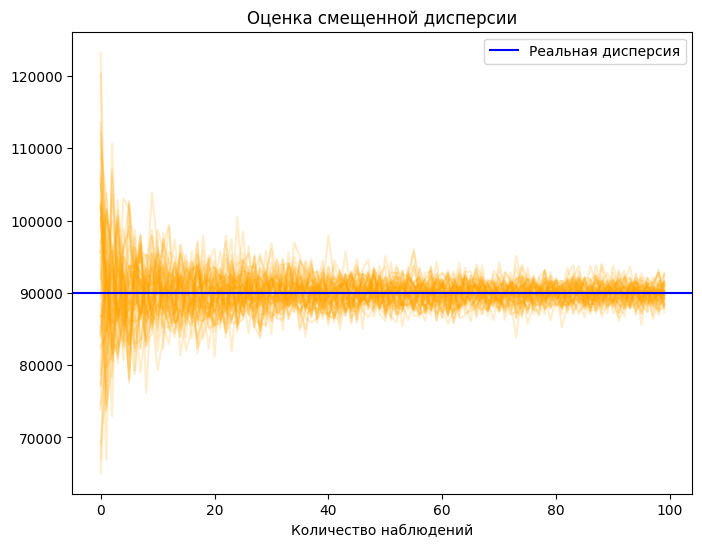

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(biased_vars, color='orange', alpha=0.2)
plt.axhline(sd**2, color='blue', label='Реальная дисперсия')
plt.title('Оценка смещенной дисперсии')
plt.xlabel('Количество наблюдений')
plt.legend()
plt.show()

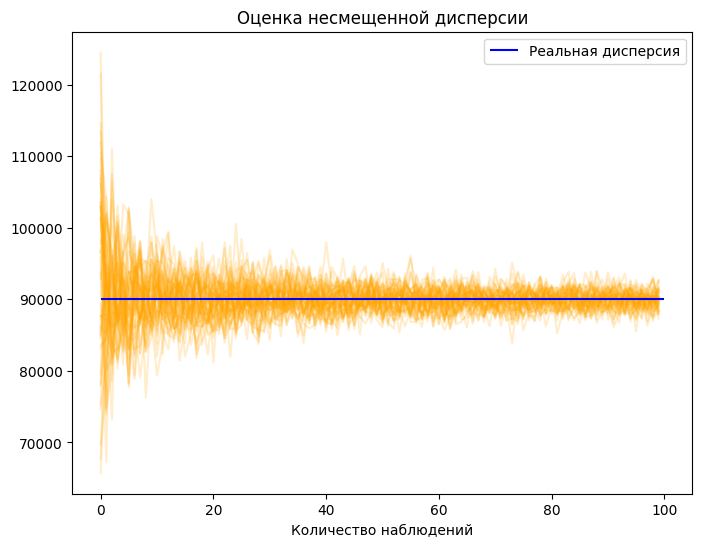

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(unbiased_vars, color='orange', alpha=0.2)
plt.hlines(sd**2, 0, 100, color='blue', label='Реальная дисперсия')
plt.title('Оценка несмещенной дисперсии')
plt.xlabel('Количество наблюдений')
plt.legend()
plt.show()

**Вывод**

На больших $n$ нет разницы, использовать ли смещённую или несмещённую оценку дисперсии.

При малых $n$ смещение хорошо заметно. По мере роста $n$ множитель $(n-1)/n$ приближается к единице, поэтому разница между двумя вариантами уменьшается.

Это хороший пример различия между **свойством при фиксированном $n$** и **асимптотическим поведением**.

Также следует отметить, что обе оценки состоятельны.

# Несмещённость не равна качеству

У оценки есть как минимум две разные характеристики:

- **смещение** показывает систематическое отклонение от параметра;
- **дисперсия** показывает разброс оценки от выборки к выборке.

Оценка может иметь маленькое смещение, но очень большой разброс. Поэтому одной несмещённости недостаточно.

## Среднеквадратичная ошибка

Для оценки $\widehat\theta$ определим **среднеквадратичную ошибку**:

$$\operatorname{MSE}_\theta(\widehat\theta)=\mathbb{E}_\theta[(\widehat\theta-\theta)^2].$$

Она раскладывается на дисперсию и квадрат смещения:

$$\operatorname{MSE}_\theta(\widehat\theta)=\operatorname{Var}_\theta(\widehat\theta)+\operatorname{Bias}_\theta(\widehat\theta)^2.$$

Для несмещённой оценки $\operatorname{Bias}_\theta(\widehat\theta)=0$, поэтому

$$\operatorname{MSE}_\theta(\widehat\theta)=\operatorname{Var}_\theta(\widehat\theta).$$

Именно поэтому при сравнении **несмещённых** оценок естественно выбирать оценку с меньшей дисперсией.

### Пример смещения и дисперсии

Рассмотрим семейство оценок среднего

$$\widehat\mu_a=a\overline X.$$

Если $\mathbb{E}[X_i]=\mu$ и $\operatorname{Var}(X_i)=\sigma^2$, то

$$\operatorname{Bias}(\widehat\mu_a)=(a-1)\mu,\qquad \operatorname{Var}(\widehat\mu_a)=\frac{a^2\sigma^2}{n}.$$

Следовательно,

$$\operatorname{MSE}(\widehat\mu_a)=\frac{a^2\sigma^2}{n}+(a-1)^2\mu^2.$$

При $a<1$ мы уменьшаем дисперсию, но платим за это смещением.

**Вывод:** несмещённость — важное, но не универсальное требование.

Если мы заранее ограничили класс оценок несмещёнными, тогда их качество удобно сравнивать по дисперсии. Если допускаются смещённые оценки, естественным критерием часто становится MSE.

# Эффективность: сравнение несмещённых оценок

Пусть $\widehat\theta_1$ и $\widehat\theta_2$ — две несмещённые оценки одного и того же параметра.

Если для всех $\theta$

$$\operatorname{Var}_\theta(\widehat\theta_1)\leq\operatorname{Var}_\theta(\widehat\theta_2),$$

то $\widehat\theta_1$ будем считать **более эффективной**: от выборки к выборке она колеблется меньше.

## Пример. Первое наблюдение против выборочного среднего

Пусть $X_1,\ldots,X_n$ независимы, $\mathbb{E}[X_i]=\mu$ и $\operatorname{Var}(X_i)=\sigma^2$.

Для оценки $\mu$ можно предложить, например,

$$\widehat\mu_1=X_1,\qquad \widehat\mu_2=\overline X.$$

Обе оценки несмещённые, но

$$\operatorname{Var}(X_1)=\sigma^2,\qquad \operatorname{Var}(\overline X)=\frac{\sigma^2}{n}.$$

При $n>1$ выборочное среднее имеет меньшую дисперсию.

Смысл можно увидеть на повторных выборках: обе оценки в среднем находятся в правильной точке, но распределение $\overline X$ значительно уже.

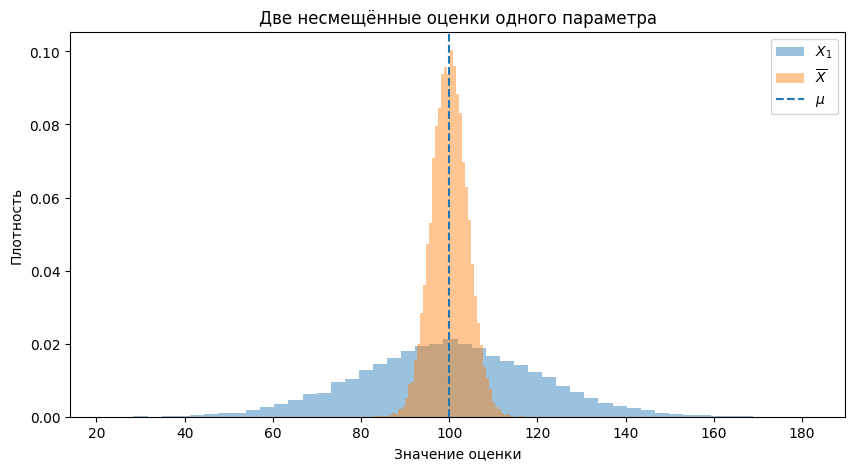

In [ ]:
rng = np.random.default_rng(42)

mu = 100
sigma = 20
n = 25
n_repeats = 20_000

samples = rng.normal(mu, sigma, size=(n_repeats, n))
x_1 = samples[:, 0]
x_bar = samples.mean(axis=1)

plt.figure(figsize=(10, 5))
plt.hist(x_1, bins=50, density=True, alpha=0.45, label=r"$X_1$")
plt.hist(x_bar, bins=50, density=True, alpha=0.45, label=r"$\overline{X}$")
plt.axvline(mu, linestyle="--", label=r"$\mu$")
plt.xlabel("Значение оценки")
plt.ylabel("Плотность")
plt.title("Две несмещённые оценки одного параметра")
plt.legend()
plt.show()

Но здесь возникает новый вопрос:

> Мы сравнили только две конкретные оценки. Откуда знать, что не существует третьей несмещённой оценки с ещё меньшей дисперсией?

Для ответа нужен **теоретический нижний предел** дисперсии.

# Информация Фишера

Пусть распределение одного наблюдения задаётся функцией вероятности или плотностью $p_\theta(x)$ и зависит от неизвестного параметра $\theta$.

Нас интересует, насколько сильно распределение наблюдений меняется при небольшом изменении $\theta$.

Если разные значения $\theta$ порождают хорошо различимые распределения, данные содержат много информации о параметре. Если распределения почти не меняются — информации мало.

## Функция вклада

Определим **функцию вклада** одного наблюдения:

$$U_\theta(X)=\frac{\partial}{\partial\theta}\log p_\theta(X).$$

Она показывает чувствительность логарифма плотности или функции вероятности наблюдения к изменению параметра $\theta$.

В англоязычной литературе $U_\theta$ обычно называется **score function**.

При стандартных условиях регулярности среднее значение функции вклада равно нулю:

$$\mathbb{E}_\theta[U_\theta(X)]=0.$$

Для непрерывного случая это следует из

$$\mathbb{E}_\theta[U_\theta(X)]=\int \frac{\partial}{\partial\theta}\log p_\theta(x)\,p_\theta(x)\,dx=\int\frac{\partial p_\theta(x)}{\partial\theta}\,dx=\frac{\partial}{\partial\theta}1=0.$$

## Определение информации Фишера

**Информацией Фишера** в одном наблюдении называется

$$I_1(\theta)=\mathbb{E}_\theta[U_\theta(X)^2].$$

Поскольку $\mathbb{E}_\theta[U_\theta(X)]=0$, можно также записать

$$I_1(\theta)=\operatorname{Var}_\theta(U_\theta(X)).$$

Чем больше $I_1(\theta)$, тем больше информации об $\theta$ несёт одно наблюдение.

При дополнительных условиях регулярности существует эквивалентная формула:

$$I_1(\theta)=-\mathbb{E}_\theta\left[\frac{\partial^2}{\partial\theta^2}\log p_\theta(X)\right].$$

Обе формулы описывают одну и ту же величину, но применять вторую можно только когда выполнены необходимые условия регулярности.

## Информация в выборке

Если $X_1,\ldots,X_n$ независимы и одинаково распределены, информация складывается:

$$I_n(\theta)=nI_1(\theta).$$

Это очень важный результат: при увеличении размера выборки в $k$ раз информация Фишера также увеличивается в $k$ раз.

Позже мы увидим, что типичный масштаб стандартной ошибки поэтому уменьшается как $1/\sqrt n$.

## Информация Фишера для среднего нормального распределения

Пусть

$$
X_1,\ldots,X_n \overset{\mathrm{iid}}{\sim} N(\mu,\sigma^2),
$$

где $\mu$ неизвестно, а $\sigma^2$ известно.

Для одного наблюдения плотность равна

$$
f_\mu(x)=\frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right).
$$

Нужно:

1. Найти score $U_\mu(X)=\frac{\partial}{\partial\mu}\log f_\mu(X)$.
2. Найти информацию Фишера $I_1(\mu)$ в одном наблюдении.
3. Найти информацию Фишера $I_n(\mu)$ во всей выборке.
4. Выписать границу Рао–Крамера для любой несмещённой оценки $\mu$.
5. Проверить, является ли $\overline X$ эффективной оценкой $\mu$.
6. Посчитать $I_n(\mu)$, границу Рао–Крамера и стандартное отклонение $\overline X$, если $n=25$, $\sigma=10$.

**Решение**

### Пункт 1. Score

Сначала возьмём логарифм плотности:

$$
\log f_\mu(x)=-\frac{1}{2}\log(2\pi\sigma^2)-\frac{(x-\mu)^2}{2\sigma^2}.
$$

Первое слагаемое от $\mu$ не зависит, поэтому его производная равна нулю.

Разберём второе слагаемое отдельно. Так как

$$
\frac{\partial}{\partial\mu}(x-\mu)^2=2(x-\mu)(-1)=-2(x-\mu),
$$

то

$$
\frac{\partial}{\partial\mu}\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
=-\frac{1}{2\sigma^2}\cdot[-2(x-\mu)]
=\frac{x-\mu}{\sigma^2}.
$$

Значит,

$$
\boxed{U_\mu(X)=\frac{X-\mu}{\sigma^2}}.
$$

### Пункт 2. Информация Фишера в одном наблюдении

По определению

$$
I_1(\mu)=\mathbb{E}\left[U_\mu(X)^2\right].
$$

Подставляем score:

$$
I_1(\mu)=\mathbb{E}\left[\frac{(X-\mu)^2}{\sigma^4}\right]
=\frac{1}{\sigma^4}\mathbb{E}[(X-\mu)^2].
$$

Но

$$
\mathbb{E}[(X-\mu)^2]=\operatorname{Var}(X)=\sigma^2.
$$

Поэтому

$$
\boxed{I_1(\mu)=\frac{1}{\sigma^2}}.
$$

Чем больше разброс $\sigma^2$, тем меньше информации о $\mu$ несёт одно наблюдение.

### Пункт 3. Информация во всей выборке

Для независимых одинаково распределённых наблюдений информация складывается:

$$
I_n(\mu)=nI_1(\mu).
$$

Следовательно,

$$
\boxed{I_n(\mu)=\frac{n}{\sigma^2}}.
$$

### Пункт 4. Граница Рао–Крамера

Для любой несмещённой оценки $\widehat\mu$ при выполнении условий регулярности

$$
\operatorname{Var}(\widehat\mu)\geq\frac{1}{I_n(\mu)}.
$$

В нашей задаче

$$
\boxed{\operatorname{Var}(\widehat\mu)\geq\frac{\sigma^2}{n}}.
$$

Это не дисперсия конкретной оценки, а нижняя граница: несмещённая оценка $\mu$ не может иметь дисперсию меньше.

### Пункт 5. Эффективность выборочного среднего

Для выборочного среднего

$$
\mathbb{E}[\overline X]=\mu,
$$

то есть оценка несмещённая.

Кроме того,

$$
\operatorname{Var}(\overline X)=\frac{\sigma^2}{n}.
$$

Это в точности граница Рао–Крамера:

$$
\operatorname{Var}(\overline X)=\frac{1}{I_n(\mu)}.
$$

Следовательно,

$$
\boxed{\overline X\text{ — эффективная оценка }\mu.}
$$

### Пункт 6. Проверка на числах

Пусть $n=25$, $\sigma=10$, тогда $\sigma^2=100$.

Информация Фишера:

$$
I_n(\mu)=\frac{25}{100}=0.25.
$$

Граница Рао–Крамера:

$$
\frac{1}{I_n(\mu)}=\frac{1}{0.25}=4.
$$

То есть минимально возможная дисперсия несмещённой оценки равна $4$.

Для $\overline X$:

$$
\operatorname{Var}(\overline X)=\frac{100}{25}=4,
\qquad
\operatorname{SD}(\overline X)=\sqrt{4}=2.
$$

Выборочное среднее снова достигает границы.

# Неравенство Рао–Крамера

Информация Фишера позволяет получить нижнюю границу дисперсии несмещённых оценок.

Пусть $\widehat\theta$ — несмещённая оценка параметра $\theta$ и выполнены условия регулярности. Тогда

$$\operatorname{Var}_\theta(\widehat\theta)\geq\frac{1}{I_n(\theta)}.$$

Это **неравенство Рао–Крамера**.

Более общий вариант нужен, если мы оцениваем не сам $\theta$, а функцию $g(\theta)$.

Если $T$ — несмещённая оценка $g(\theta)$, то

$$\operatorname{Var}_\theta(T)\geq\frac{[g'(\theta)]^2}{I_n(\theta)}.$$

## Условия регулярности

Для стандартной формы неравенства Рао–Крамера обычно требуется, чтобы:

- носитель распределения не зависел от $\theta$;
- $p_\theta(x)$ была достаточно гладкой по $\theta$;
- производную по $\theta$ можно было переносить под знак суммы или интеграла;
- информация Фишера существовала и была конечной.

Эти условия важны: неравенство нельзя применять механически к любой параметрической модели.

# Почему возникает граница Рао–Крамера

Обозначим функцию вклада всей выборки через

$$U_\theta=\frac{\partial}{\partial\theta}\log p_\theta(X_1,\ldots,X_n).$$

При условиях регулярности

$$\mathbb{E}_\theta[U_\theta]=0,\qquad \operatorname{Var}_\theta(U_\theta)=I_n(\theta).$$

Пусть $\widehat\theta$ несмещённа, то есть $\mathbb{E}_\theta[\widehat\theta]=\theta$.

Дифференцируя это равенство по $\theta$, получаем

$$1=\frac{\partial}{\partial\theta}\mathbb{E}_\theta[\widehat\theta]=\mathbb{E}_\theta[\widehat\theta U_\theta].$$

Так как $\mathbb{E}_\theta[U_\theta]=0$, отсюда

$$\operatorname{Cov}_\theta(\widehat\theta,U_\theta)=1.$$

По неравенству Коши–Шварца

$$\operatorname{Cov}(\widehat\theta,U_\theta)^2\leq\operatorname{Var}(\widehat\theta)\operatorname{Var}(U_\theta).$$

Подставляем $\operatorname{Cov}(\widehat\theta,U_\theta)=1$ и $\operatorname{Var}(U_\theta)=I_n(\theta)$:

$$1\leq\operatorname{Var}(\widehat\theta)I_n(\theta).$$

Следовательно,

$$\boxed{\operatorname{Var}(\widehat\theta)\geq\frac{1}{I_n(\theta)}}.$$

Равенство в неравенстве Коши–Шварца достигается только тогда, когда центрированная оценка пропорциональна функции вклада:

$$\widehat\theta-\theta=c(\theta)U_\theta.$$

Поэтому граница Рао–Крамера достигается далеко не в каждой модели: для этого форма оценки должна быть согласована с формой score-функции.

Смысл границы:

> распределение данных само задаёт предел того, насколько мала может быть дисперсия **несмещённой** оценки параметра при данном $n$.

Это уже не сравнение двух конкретных формул, а утверждение сразу обо всём классе несмещённых оценок.

# Пример. Среднее нормального распределения достигает границы

Для $X_i\sim\mathcal N(\mu,\sigma^2)$ с известной $\sigma^2$ мы получили

$$I_n(\mu)=\frac{n}{\sigma^2}.$$

По Рао–Крамеру любая несмещённая оценка $\mu$ должна удовлетворять

$$\operatorname{Var}(\widehat\mu)\geq\frac{\sigma^2}{n}.$$

Но для выборочного среднего

$$\operatorname{Var}(\overline X)=\frac{\sigma^2}{n}.$$

Значит, $\overline X$ достигает теоретически минимально возможной дисперсии.

# Эффективная оценка

Для несмещённой оценки параметра $\theta$ определим коэффициент эффективности относительно границы Рао–Крамера:

$$\operatorname{Eff}_\theta(\widehat\theta)=\frac{1/I_n(\theta)}{\operatorname{Var}_\theta(\widehat\theta)}.$$

По неравенству Рао–Крамера

$$0<\operatorname{Eff}_\theta(\widehat\theta)\leq1.$$

Если $\operatorname{Eff}_\theta(\widehat\theta)=1$, оценка называется **эффективной**.

Для среднего нормального распределения

$$\operatorname{Eff}_\mu(\overline X)=\frac{\sigma^2/n}{\sigma^2/n}=1.$$

Поэтому $\overline X$ — эффективная оценка $\mu$ в этой модели.

## Пример. Конверсия

Для $X_i\sim\operatorname{Bernoulli}(p)$ выборочная конверсия $\widehat p=\overline X$ имеет дисперсию

$$\operatorname{Var}(\widehat p)=\frac{p(1-p)}{n}.$$

При этом

$$\frac{1}{I_n(p)}=\frac{p(1-p)}{n}.$$

Следовательно, $\widehat p$ также достигает границы Рао–Крамера и является эффективной оценкой $p$.

# Оптимальность

Слово **«оптимальная»** не имеет смысла без указания критерия и класса оценок.

В рамках этой темы будем рассматривать **оптимальность среди несмещённых оценок по дисперсии**.

Несмещённая оценка $\widehat\theta^*$ называется **оптимальной несмещённой**, если для любой другой несмещённой оценки $\widetilde\theta$

$$\operatorname{Var}_\theta(\widehat\theta^*)\leq\operatorname{Var}_\theta(\widetilde\theta)$$

для всех допустимых значений $\theta$.

Такую оценку также называют **UMVU-оценкой** — uniformly minimum-variance unbiased estimator.

## Связь эффективности и оптимальности

Если несмещённая оценка достигает границы Рао–Крамера, то меньшей дисперсии у другой несмещённой оценки быть не может.

Поэтому

$$\text{эффективная оценка}\quad\Longrightarrow\quad\text{оптимальная несмещённая оценка}.$$

Обратное утверждение в общем случае неверно: оптимальная несмещённая оценка может существовать даже тогда, когда граница Рао–Крамера недостижима.

Терминология в разных учебниках может немного отличаться. В рамках курса зафиксируем:

- **более эффективная** — имеет меньшую дисперсию при сравнении несмещённых оценок;
- **эффективная** — достигает границы Рао–Крамера;
- **оптимальная несмещённая** — имеет минимальную дисперсию среди всех несмещённых оценок.

# Когда Рао–Крамер применять нельзя

Рассмотрим

$$X\sim U(0,\theta).$$

Плотность равна

$$p_\theta(x)=\frac{1}{\theta}\mathbb{I}\{0\leq x\leq\theta\}.$$

Здесь **носитель распределения зависит от $\theta$**. Поэтому одно из ключевых условий регулярности нарушено.

Если внутри носителя формально продифференцировать $\log p_\theta(x)=-\log\theta$, получится

$$U_\theta(X)=-\frac{1}{\theta}.$$

Но тогда

$$\mathbb{E}_\theta[U_\theta(X)]=-\frac{1}{\theta}\neq0.$$

Это сразу показывает, что стандартная схема вывода информации Фишера и границы Рао–Крамера здесь не работает.

Для этой модели, например, можно построить несмещённую оценку через максимум выборки:

$$\widehat\theta=\frac{n+1}{n}X_{(n)},\qquad X_{(n)}=\max(X_1,\ldots,X_n).$$

Её дисперсия равна

$$\operatorname{Var}(\widehat\theta)=\frac{\theta^2}{n(n+2)}.$$

Это не противоречит Рао–Крамеру: стандартные условия теоремы здесь просто не выполнены.

# Свойства оценок: фиксированное $n$ и асимптотика

Теперь можно разделить свойства точечных оценок на две группы.

| Свойство | Тип | Основной вопрос |
|---|---|---|
| Несмещённость | фиксированное $n$ | $\mathbb{E}[\widehat\theta]=\theta$? |
| Дисперсия / MSE | фиксированное $n$ | Насколько сильно ошибается оценка? |
| Эффективность | фиксированное $n$ | Достигает ли дисперсия теоретического минимума? |
| Оптимальность | фиксированное $n$ | Лучшая ли это несмещённая оценка по дисперсии? |
| Состоятельность | $n\to\infty$ | Сходится ли $\widehat\theta_n$ к $\theta$? |
| Асимптотическая нормальность | $n\to\infty$ | Как устроены флуктуации оценки при больших $n$? |

Важно, что эти свойства **не заменяют друг друга**.

Например, оценка может быть:

- смещённой при каждом конечном $n$, но состоятельной;
- несмещённой, но иметь большую дисперсию;
- состоятельной, но неудобной на реальных размерах выборки.

Поэтому качество оценки обычно нельзя описать одним словом.

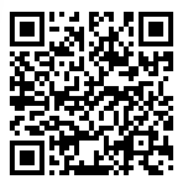